# SCANIA Component X: Synthetic Generation & Few-Shot Transfer Learning

Generative models, such as Conditional Variational Autoencoders (CVAE), require information from the target domain to bridge the distributional gap. In real-world industrial scenarios, acquiring labeled target data is expensive and slow. This notebook answers a critical question: **how much target data is actually necessary to salvage predictive performance?**

We run a strict budget sweep on our most extreme domain shift (e.g., `Cat0` vs `Cat2`), comparing the Transfer Penalty across different data augmentation strategies:
- **Source Only**: The baseline Random Forest trained exclusively on the Source domain (Stage 2 reproduction).
- **Source + N Real Target**: Adding a tiny budget ($N$) of actual Target anomalies.
- **Source + N Synthetic (CVAE)**: Training a generative model on the tiny $N$ budget to hallucinate new Target anomalies. 
- **Amplification (5N / 10N)**: Forcing the CVAE to multiply the limited target information to test generative stability and mode collapse resistance.

## 1. Environment Setup & Data Preparation
We initialize the PyTorch environment for deep learning and reconstruct the exact active feature space (aggregated histograms and counters) engineered in Stage 2.

In [1]:
import os
import ot 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.linalg
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score

# Deep Learning dependencies for CVAE
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics.pairwise import rbf_kernel

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Guarantee reproducibility across the generative pipeline
np.random.seed(42)
torch.manual_seed(42)

print('PyTorch version:', torch.__version__)
print('Hardware Target:', 'GPU (CUDA) available' if torch.cuda.is_available() else 'CPU only')

# --- DATA LOADING & FEATURE ENGINEERING (From Stage 2) ---
print("\nLoading SCANIA dataset and building feature space...")
train_op = pd.read_csv('../data/train_operational_readouts.csv')
train_tte = pd.read_csv('../data/train_tte.csv')
train_specs = pd.read_csv('../data/train_specifications.csv')

df_merged = pd.merge(train_op, train_tte, on='vehicle_id', how='inner')
df_full = pd.merge(df_merged, train_specs, on='vehicle_id', how='left')

exclude_cols = ['vehicle_id', 'time_step', 'length_of_study_time_step', 'in_study_repair']
op_cols = [c for c in df_full.columns if c not in exclude_cols and c not in train_specs.columns]

# Rebuild the exact feature space
prefix_dict = {}
for col in op_cols:
    prefix = str(col).split('_')[0]
    prefix_dict.setdefault(prefix, []).append(col)

agg_features, counters, missing_flags = [], [], []
for prefix, bins in prefix_dict.items():
    if len(bins) > 1:
        feature_name = f'total_exposure_{prefix}'
        df_full[feature_name] = df_full[bins].sum(axis=1, min_count=1)
        agg_features.append(feature_name)
        
        flag_name = f'{feature_name}_was_missing'
        df_full[flag_name] = df_full[feature_name].isna().astype(int)
        missing_flags.append(flag_name)
    else:
        counters.append(bins[0])

final_features = agg_features + counters + missing_flags
df_full[final_features] = df_full[final_features].fillna(0)

print(f"Feature matrix established: {len(final_features)} dimensional vector space.")

PyTorch version: 2.10.0+cpu
Hardware Target: CPU only

Loading SCANIA dataset and building feature space...
Feature matrix established: 20 dimensional vector space.


In [2]:
# Identify the categorical specification column used to define the Cross-Specs scenario
cat_col = df_full.select_dtypes(include=['object']).columns[0]

## 3. The Target-Budget Protocol and Source-Only Baselines

**Pairs** (chosen based on Stage 2 results, representing the most extreme geometric distances and transfer penalties):

| Pair | Axis | Penalty (Stage 2) | Budget Grid (N Anomalous Vehicles) |
|---|---|---|---|
| Cat0/1 $\rightarrow$ Cat2 | Cross-Specs | ~ 0.21 | [5, 10, 20, 40] |
| Q1 $\rightarrow$ Q4 | Temporal Wear | ~ 0.28 | [5, 10, 20, 40] |

Both penalties are large enough for the augmentation question to matter, and both targets keep a stratified budget pool of unique vehicles that supports the $N$ grid.

**Budget protocol.** To prevent Data Leakage, the target budget $N$ does not represent individual rows, but **unique anomalous vehicles**. For each draw, the reserve pool of anomalous target vehicles is shuffled into a fixed ordering; the budget at size $N$ consists of all operational readings from the first $N$ vehicles of that ordering. Budgets are **nested** (budget@5 is inside budget@10, and so on). Two draws (seeds 42 and 43) capture the budget-sampling variance that dominates at tiny $N$.

**Scenarios per budget N** (every penalty is the mean over the 3 RF seeds using `GroupShuffleSplit`; every distance is the conditional SWD/MMD/FD of the training set against the target-eval test set):

1. `source_only` - the Stage 2 anchor (no target data).
2. `real` - source + the $N$ real budget vehicles.
3. `budget_N` - source + synthetic instances from the **budget-only CVAE** (trained on the $N$ budget vehicles from scratch).
4. `synth_N` - source + synthetic instances from the **source-pretrained, budget-finetuned CVAE** (the transfer generator).
5. `synth_5N`, `synth_10N` - the amplification control: same transferred CVAE, generating 5x or 10x more synthetic anomalies to check whether the generator can multiply the information contained in the few target examples.

In [3]:
def sample_by_vehicle(df, n_samples, features, seed=42, agg='mean'):
    """
    Samples distinct VEHICLES (not individual time-step rows) to prevent pseudoreplication.
    Enforces independence between observations.
    """
    rng = np.random.default_rng(seed)
    unique_vehicles = df['vehicle_id'].unique()
    n = min(n_samples, len(unique_vehicles))
    chosen = rng.choice(unique_vehicles, size=n, replace=False)

    subset = df[df['vehicle_id'].isin(chosen)]
    if agg == 'mean':
        # Flatten longitudinal profile to a single representative row per vehicle
        return subset.groupby('vehicle_id')[features].mean().values
    else:
        return subset.groupby('vehicle_id').sample(1, random_state=seed)[features].values

In [4]:
# --- DISTANCE METRICS ---
def mmd_rbf(X, Y, gamma=0.1):
    """Computes Maximum Mean Discrepancy using an RBF kernel."""
    XX, YY, XY = rbf_kernel(X, X, gamma), rbf_kernel(Y, Y, gamma), rbf_kernel(X, Y, gamma)
    return XX.mean() + YY.mean() - 2 * XY.mean()

def frechet_distance(X, Y, eps=1e-6):
    """Computes Fréchet Distance between two multivariate Gaussians fitted to the data."""
    mu1, sigma1 = X.mean(axis=0), np.cov(X, rowvar=False)
    mu2, sigma2 = Y.mean(axis=0), np.cov(Y, rowvar=False)
    
    # Regularization for numerical stability (prevents singular matrices in high dimensions)
    sigma1 += np.eye(sigma1.shape[0]) * eps
    sigma2 += np.eye(sigma2.shape[0]) * eps
    
    diff = mu1 - mu2
    covmean = scipy.linalg.sqrtm(sigma1.dot(sigma2))
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return diff.dot(diff) + np.trace(sigma1) + np.trace(sigma2) - 2 * np.trace(covmean)

# --- LEAK-FREE TRANSFER LEARNING PIPELINE ---
def run_transfer_trials_grouped(src_df, tgt_df, features, target_col='in_study_repair', current_seed=42):
    """
    Trains and evaluates a Random Forest utilizing GroupShuffleSplit to prevent Data Leakage.
    Applies strict undersampling on the majority class to handle heavy industrial imbalance.
    """
    # Isolate vehicles geographically/logically using GroupShuffleSplit
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=current_seed)
    train_idx, test_idx = next(gss.split(src_df, src_df[target_col], groups=src_df['vehicle_id']))
    
    df_train_full = src_df.iloc[train_idx]
    df_test = src_df.iloc[test_idx]
    
    df_train_majority = df_train_full[df_train_full[target_col] == 0]
    df_train_minority = df_train_full[df_train_full[target_col] == 1]
    
    # Enforce balance via undersampling dictated by the current stochastic seed
    if len(df_train_minority) > 0 and len(df_train_majority) > len(df_train_minority):
        df_train_majority_downsampled = resample(
            df_train_majority, replace=False, n_samples=len(df_train_minority), random_state=current_seed
        )
        df_train_balanced = pd.concat([df_train_majority_downsampled, df_train_minority])
    else:
        df_train_balanced = df_train_full
        
    X_train_s, y_train_s = df_train_balanced[features], df_train_balanced[target_col]
    X_test_s, y_test_s = df_test[features], df_test[target_col]
    X_t, y_t = tgt_df[features], tgt_df[target_col]
    
    # Train robust baseline
    rf = RandomForestClassifier(n_estimators=100, random_state=current_seed, n_jobs=-1)
    rf.fit(X_train_s, y_train_s)
    
    # Calculate performance delta
    rf_baseline = f1_score(y_test_s, rf.predict(X_test_s), zero_division=0)
    rf_transfer = f1_score(y_t, rf.predict(X_t), zero_division=0)
    
    return rf_baseline, rf_transfer, (rf_baseline - rf_transfer)

In [5]:
# --- REBUILD TEMPORAL QUANTILES (Required for Q1 -> Q4 scenario) ---
veh_durations = df_full.groupby('vehicle_id')['length_of_study_time_step'].max()
q25, q75 = veh_durations.quantile([0.25, 0.75])

veh_Q1 = veh_durations[veh_durations <= q25].index
veh_Q4 = veh_durations[veh_durations > q75].index

# ==========================================
# 1. SCENARIO SETUP & NESTED BUDGET PROTOCOL
# ==========================================
PAIRS = {
    'Cross-Specs (Cat0 -> Cat1)': {
        'src_mask': df_full[cat_col] == 'Cat0',   # ⚠️ solo Cat0 come source ora, 
                                                     # non più Cat0+Cat1 combinati
        'tgt_mask': df_full[cat_col] == 'Cat1',
        'N_GRID': [5, 10, 20, 40]
    },
    'Temporal Drift (Q1 -> Q4)': {
        'src_mask': df_full['vehicle_id'].isin(veh_Q1),
        'tgt_mask': df_full['vehicle_id'].isin(veh_Q4),
        'N_GRID': [5, 10, 20, 40]
    }
}

In [6]:
DRAW_SEEDS = [42, 43]
RF_SEEDS = [42, 123, 999] # Reduced to 3 seeds for computational efficiency in the sweep

def get_vehicle_budget_order(pool_df, seed):
    """
    Returns a shuffled list of unique anomalous vehicle_ids from the reserve pool.
    Budgets will be drawn sequentially from this list to ensure nesting.
    """
    rng = np.random.default_rng(seed)
    anomalous_vehicles = pool_df[pool_df['in_study_repair'] == 1]['vehicle_id'].unique()
    rng.shuffle(anomalous_vehicles)
    return anomalous_vehicles.tolist()

# Prepare the data splits for both pairs
for pair_name, spec in PAIRS.items():
    src = df_full[spec['src_mask']].copy()
    tgt_full = df_full[spec['tgt_mask']].copy()
    
    tgt_anomalies = tgt_full[tgt_full['in_study_repair'] == 1]
    gss = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
    reserve_idx, eval_idx = next(gss.split(tgt_anomalies, groups=tgt_anomalies['vehicle_id']))
    
    reserve_veh = tgt_anomalies.iloc[reserve_idx]['vehicle_id'].unique()
    eval_veh = tgt_anomalies.iloc[eval_idx]['vehicle_id'].unique()

    tgt_nominal_veh = tgt_full[tgt_full['in_study_repair'] == 0]['vehicle_id'].unique()
    test_df = tgt_full[
        tgt_full['vehicle_id'].isin(eval_veh) | tgt_full['vehicle_id'].isin(tgt_nominal_veh)
    ]
    pool_df = tgt_full[tgt_full['vehicle_id'].isin(reserve_veh)]
    
    spec['src'] = src
    spec['test'] = test_df
    spec['pool'] = pool_df
    spec['orders'] = {d: get_vehicle_budget_order(pool_df, d) for d in DRAW_SEEDS}

    print(f"\n{pair_name}:")
    print(f"  Source: {src['vehicle_id'].nunique()} vehicles")
    print(f"  Target Eval (Strict Test): {test_df['vehicle_id'].nunique()} vehicles")
    print(f"  Target Reserve (Budget Pool): {pool_df['vehicle_id'].nunique()} vehicles")

# --- Verifica DOPO che tutte le coppie sono state popolate ---
print("\nVerifica budget grid vs pool disponibile:")
for pair_name, spec in PAIRS.items():
    pool_size = len(spec['orders'][DRAW_SEEDS[0]])
    print(f"{pair_name}: pool disponibile = {pool_size} veicoli anomali")
    
    max_n_requested = max(spec['N_GRID'])
    if pool_size < max_n_requested:
        print(f"  ⚠️ Budget massimo richiesto ({max_n_requested}) supera il pool disponibile ({pool_size}).")
        spec['N_GRID'] = [n for n in spec['N_GRID'] if n <= pool_size]
        print(f"  Griglia adattata: {spec['N_GRID']}")

# ==========================================
# 2. SOURCE-ONLY ANCHOR (BASELINE REPRODUCTION)
# ==========================================
print("\nComputing Source-Only Baselines...")
anchors = {}

for name, spec in PAIRS.items():
    pens = []
    src_df = spec['src']
    test_df = spec['test']
    
    # Calculate initial distances (using the sample_by_vehicle function from Stage 2 logic)
    src_anomalies = src_df[src_df['in_study_repair'] == 1]
    tgt_eval_anomalies = test_df[test_df['in_study_repair'] == 1]
    MIN_SAMPLES_FOR_COV = 3 * len(final_features)

    n_src = src_anomalies['vehicle_id'].nunique()
    n_tgt = tgt_eval_anomalies['vehicle_id'].nunique()
    n_samples = min(500, n_src, n_tgt)

    print(f"  [Distance check] veicoli anomali disponibili -> source: {n_src}, target eval: {n_tgt}")

    if n_samples < MIN_SAMPLES_FOR_COV:
        print(f"  ⚠️ Solo {n_samples} veicoli disponibili (soglia minima: {MIN_SAMPLES_FOR_COV}). FD sarà instabile.")
        dist = {'SWD': np.nan, 'MMD': np.nan, 'FD': np.nan}  # o salta il calcolo
    else:
        X = sample_by_vehicle(src_anomalies, n_samples, final_features, seed=42)
        Y = sample_by_vehicle(tgt_eval_anomalies, n_samples, final_features, seed=42)
        scaler = StandardScaler().fit(X)
        X_scaled, Y_scaled = scaler.transform(X), scaler.transform(Y)
        np.random.seed(42)  
        swd_val = ot.sliced_wasserstein_distance(X_scaled, Y_scaled, n_projections=50)
        dist = {
            'SWD': swd_val,
            'MMD': mmd_rbf(X_scaled, Y_scaled, gamma=0.1),
            'FD': frechet_distance(X_scaled, Y_scaled)
        }
    
    # Execute Transfer Penalty Trials
    for seed in RF_SEEDS:
        _, _, penalty = run_transfer_trials_grouped(src_df, test_df, final_features, current_seed=seed)
        pens.append(penalty)
        
    anchors[name] = (pens, dist)
    
    print(f"{name}:")
    print(f"  Transfer Penalty: {np.mean(pens):.3f} ± {np.std(pens):.3f}")
    print(f"  Distance -> SWD: {dist['SWD']:.3f} | MMD: {dist['MMD']:.3f} | FD: {dist['FD']:.2f}")


Cross-Specs (Cat0 -> Cat1):
  Source: 19221 vehicles
  Target Eval (Strict Test): 4145 vehicles
  Target Reserve (Budget Pool): 146 vehicles

Temporal Drift (Q1 -> Q4):
  Source: 5903 vehicles
  Target Eval (Strict Test): 5741 vehicles
  Target Reserve (Budget Pool): 146 vehicles

Verifica budget grid vs pool disponibile:
Cross-Specs (Cat0 -> Cat1): pool disponibile = 146 veicoli anomali
Temporal Drift (Q1 -> Q4): pool disponibile = 146 veicoli anomali

Computing Source-Only Baselines...
  [Distance check] veicoli anomali disponibili -> source: 1977, target eval: 147
Cross-Specs (Cat0 -> Cat1):
  Transfer Penalty: 0.128 ± 0.006
  Distance -> SWD: 0.748 | MMD: 0.043 | FD: 15.50
  [Distance check] veicoli anomali disponibili -> source: 708, target eval: 147
Temporal Drift (Q1 -> Q4):
  Transfer Penalty: 0.330 ± 0.021
  Distance -> SWD: 1.949 | MMD: 0.290 | FD: 90.79


## 4. The Class-Conditioned VAE (CVAE) Generator

To hallucinate realistic target-domain anomalies from a severely constrained budget, we implement a Class-Conditioned Variational Autoencoder (CVAE) from scratch in PyTorch. The architecture injects a one-hot encoded class vector into both the encoder and decoder, forcing the latent space to decouple the physical component signature from the binary failure state. 

We evaluate two distinct training paradigms to see which best survives data starvation:
1. **Budget-Only CVAE**: Trained entirely from scratch using only the tiny target budget.
2. **Transfer Generator (Source-Pretrained + Budget-Finetuned)**: Pre-trained on the abundant source domain to learn the general physics and sensor relationships of the component, then fine-tuned on the tiny target budget. 

**Crucial Standardization Detail:** During fine-tuning, the data is standardized using the *target budget's* scaler (mean and std), rather than forcing the source's scaler. Imposing a source-fixed standardization on a shifted target domain turns the budget points into extreme outliers, inflating the posterior KL divergence and causing the generator to ignore the target data entirely (mode collapse back to the source distribution).

In [7]:
import copy
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR

def set_random_seed(seed: int):
    """Enforces absolute stochastic reproducibility across PyTorch and Numpy."""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)

class CVAE(nn.Module):
    """
    Class-conditioned Variational Autoencoder. 
    The class condition is concatenated to both the input and the latent vector.
    """
    def __init__(self, input_dim: int, n_classes: int = 2, latent_dim: int = 4, hidden: int = 32):
        super().__init__()
        self.input_dim = input_dim
        self.n_classes = n_classes
        self.latent_dim = latent_dim
        
        # Encoder: (Features + Class) -> Hidden -> Hidden -> Latent (Mu / LogVar)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim + n_classes, hidden), 
            nn.ReLU(),
            nn.Linear(hidden, hidden), 
            nn.ReLU(),
        )
        self.mu_head = nn.Linear(hidden, latent_dim)
        self.logvar_head = nn.Linear(hidden, latent_dim)

        # Decoder: (Latent + Class) -> Hidden -> Hidden -> Features
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + n_classes, hidden), 
            nn.ReLU(),
            nn.Linear(hidden, hidden), 
            nn.ReLU(),
            nn.Linear(hidden, input_dim),
        )

    def encode(self, x: torch.Tensor, c: torch.Tensor):
        h = self.encoder(torch.cat([x, c], dim=1))
        return self.mu_head(h), self.logvar_head(h)

    def reparameterize(self, mu: torch.Tensor, logvar: torch.Tensor):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)

    def decode(self, z: torch.Tensor, c: torch.Tensor):
        return self.decoder(torch.cat([z, c], dim=1))

    def forward(self, x: torch.Tensor, c: torch.Tensor):
        mu, logvar = self.encode(x, c)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, c), mu, logvar

def elbo_loss(x, x_rec, mu, logvar, beta=1.0):
    """Computes the Evidence Lower Bound (ELBO): Reconstruction Loss + Beta * KL Divergence."""
    recon = F.mse_loss(x_rec, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu ** 2 - torch.exp(logvar))
    return recon + beta * kl, recon, kl

def standardize(X: np.ndarray):
    """Calculates standardization stats, enforcing a strict variance floor to prevent division by zero."""
    mu = X.mean(axis=0)
    sd = X.std(axis=0)
    sd[sd < 1e-12] = 1.0
    return mu, sd

def train_loop(model, X, y, epochs, lr, batch_size=16):
    y_idx = np.where(y == 0, 0, 1)
    Y_oh = np.zeros((len(y), 2))
    Y_oh[np.arange(len(y)), y_idx] = 1.0
    
    counts = np.bincount(y_idx, minlength=2)
    weights = np.where(counts > 0, 1.0 / counts.astype(np.float64), 0.0)
    
    sampler = WeightedRandomSampler(weights[y_idx], num_samples=len(y), replacement=True)
    loader = DataLoader(
        TensorDataset(torch.tensor(X.astype(np.float32)), torch.tensor(Y_oh, dtype=torch.float32)),
        batch_size=min(batch_size, len(y)), sampler=sampler    # ora parametrico
    )

    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = CosineAnnealingLR(opt, T_max=epochs, eta_min=lr * 1e-2)

    kl_last = np.nan
    for _ in range(epochs):
        model.train()
        for xb, cb in loader:
            opt.zero_grad()
            x_rec, mu, lv = model(xb, cb)
            loss, _, kl = elbo_loss(xb, x_rec, mu, lv, beta=1.0)
            loss.backward()
            opt.step()
        sched.step()
        kl_last = kl.item()

    return model, kl_last


def train_budget_cvae(budget_df, seed, epochs=200, lr=1e-3, batch_size=16):
    X = budget_df[final_features].values.astype(np.float64)
    y = budget_df['in_study_repair'].values.astype(np.int64)
    mu, sd = standardize(X)
    
    set_random_seed(seed)
    model = CVAE(input_dim=X.shape[1], n_classes=2)
    model, kl = train_loop(model, (X - mu) / sd, y, epochs, lr, batch_size=batch_size)
    return model, mu, sd, kl


def pretrain_source_cvae(source_df, seed=42, epochs=30, lr=1e-3, batch_size=256):
    # epochs ridotti a 30 (non 200): con ~900k righe hai comunque migliaia
    # di gradient step per epoca, non serve arrivare a 200 epoche piene
    X = source_df[final_features].values.astype(np.float64)
    y = source_df['in_study_repair'].values.astype(np.int64)
    mu, sd = standardize(X)
    
    set_random_seed(seed)
    model = CVAE(input_dim=X.shape[1], n_classes=2)
    model, kl = train_loop(model, (X - mu) / sd, y, epochs, lr, batch_size=batch_size)
    return model, mu, sd, kl

def finetune_cvae(src_model, budget_df, seed, epochs=200, lr=1e-3):
    """
    Fine-tunes the source-pretrained CVAE using the target budget.
    Crucially, it recalculates mu and sd strictly on the budget to prevent outlier inflation.
    """
    X = budget_df[final_features].values.astype(np.float64)
    y = budget_df['in_study_repair'].values.astype(np.int64)
    mu, sd = standardize(X)
    
    model = copy.deepcopy(src_model)
    set_random_seed(seed)
    model, kl = train_loop(model, (X - mu) / sd, y, epochs, lr)
    return model, mu, sd, kl

def generate_sample(model, feat_mu, feat_sd, n_per_class, seed=42):
    """
    Forces the decoder to hallucinate n_per_class synthetic samples.
    The outputs are un-standardized back to the original physical scale of the target domain.
    """
    X_parts, y_parts = [], []
    model.eval()
    with torch.no_grad():
        for c in [0, 1]:
            g = torch.Generator().manual_seed(seed + c)
            c_oh = torch.zeros(1, model.n_classes)
            c_oh[0, c] = 1.0
            
            z = torch.randn(n_per_class, model.latent_dim, generator=g)
            x_std = model.decode(z, c_oh.repeat(n_per_class, 1))
            
            # Project back to original physical sensor space
            X_parts.append((x_std.numpy() * feat_sd) + feat_mu)
            y_parts.append(np.full(n_per_class, c))
            
    return np.vstack(X_parts), np.concatenate(y_parts).astype(np.int64)

In [8]:
import time
t0 = time.time()
_, _, _, kl = pretrain_source_cvae(PAIRS['Cross-Specs (Cat0 -> Cat1)']['src'], epochs=1, batch_size=256)
print(f"Tempo per 1 epoca: {time.time()-t0:.1f}s")

Tempo per 1 epoca: 26.0s


## 5. The Target-Fraction Budget Sweep

To rigorously answer how much target data is required to salvage predictive performance, we execute a budget sweep. For each domain pair, at each budget $N$ (number of target vehicles), and across multiple stochastic draws, we evaluate:

1. **real**: Source + $N$ real target anomalous vehicles.
2. **budget_N**: Source + Synthetic target data generated by the Budget-Only CVAE.
3. **synth_N**: Source + Synthetic target data generated by the Source-Pretrained & Finetuned CVAE.
4. **synth_5N / synth_10N**: Amplification scenarios to test if the CVAE can successfully multiply the information contained in the tiny target budget without collapsing.

Each augmented training set is evaluated for its Transfer Penalty (using a 3-seed Random Forest) and its geometric distance to the isolated Target Eval set.

In [9]:
# --- HELPER DISTANCE FUNCTION FOR THE SWEEP ---
def compute_sweep_distances(train_df, test_df, features, sample_size=500):
    src_anomalies = train_df[train_df['in_study_repair'] == 1]
    tgt_anomalies = test_df[test_df['in_study_repair'] == 1]
    
    has_synthetic = (
        'vehicle_id' in src_anomalies.columns
        and src_anomalies['vehicle_id'].astype(str).str.contains('SYNTH').any()
    )
    
    if 'vehicle_id' not in src_anomalies.columns or has_synthetic:
        X = src_anomalies[features].sample(min(sample_size, len(src_anomalies)), replace=True, random_state=42).values
    else:
        X = sample_by_vehicle(src_anomalies, sample_size, features, seed=42)
        
    Y = sample_by_vehicle(tgt_anomalies, sample_size, features, seed=42)
    
    scaler = StandardScaler().fit(X)
    X_scaled, Y_scaled = scaler.transform(X), scaler.transform(Y)
    
    return {
        'SWD': ot.sliced_wasserstein_distance(X_scaled, Y_scaled, n_projections=50),
        'MMD': mmd_rbf(X_scaled, Y_scaled, gamma=0.1),
        'FD': frechet_distance(X_scaled, Y_scaled)
    }

# --- MAIN SWEEP EXECUTION ---

def run_sweep(name: str, spec: dict, seeds: list = RF_SEEDS):
    """Executes the full generative augmentation sweep for a given Source-Target pair."""
    src, test, pool = spec['src'], spec['test'], spec['pool']
    
    # 1. Pre-train CVAE on the massive Source Domain
    src_model, _, _, src_kl = pretrain_source_cvae(src)
    print(f'{name} -> Source-Pretrained CVAE Final KL: {src_kl:.4f}')

    rows = [] 
    for N in spec['N_GRID']:
        for draw in DRAW_SEEDS:
            # Budget Sampling: N anomalous vehicles + N nominal vehicles to maintain basic balance
            budget_anom_veh = spec['orders'][draw][:N]
            
            rng = np.random.default_rng(draw)
            pool_normals = pool[pool['in_study_repair'] == 0]['vehicle_id'].unique()
            budget_norm_veh = rng.choice(pool_normals, size=min(N, len(pool_normals)), replace=False)
            
            budget_df = pool[pool['vehicle_id'].isin(budget_anom_veh) | 
                             pool['vehicle_id'].isin(budget_norm_veh)].copy()

            # 2. Train Generative Models on the Budget
            b_model, b_mu, b_sd, b_kl = train_budget_cvae(budget_df, seed=1000 + draw)
            t_model, t_mu, t_sd, t_kl = finetune_cvae(src_model, budget_df, seed=1000 + draw)
            
            print(f'  N={N:2d} | Draw={draw} | Budget-Only KL {b_kl:.4f} | Finetuned KL {t_kl:.4f}')

            def synth_df(n_per_class: int, model, mu, sd):
                """Helper to generate and format synthetic instances."""
                Xg, yg = generate_sample(model, mu, sd, n_per_class)
                df_gen = pd.DataFrame(Xg, columns=final_features)
                df_gen['in_study_repair'] = yg
                # Assign dummy vehicle IDs so GroupShuffleSplit doesn't crash during evaluation
                df_gen['vehicle_id'] = [f'SYNTH_{draw}_{i}' for i in range(len(yg))]
                return df_gen

            # Target roughly the same volume of data as the real budget
            n_rows_per_class = len(budget_df) // 2 

            scenarios = {
                'real': budget_df,
                'budget_N': synth_df(n_rows_per_class, b_model, b_mu, b_sd),
                'synth_N': synth_df(n_rows_per_class, t_model, t_mu, t_sd),
                'synth_5N': synth_df(5 * n_rows_per_class, t_model, t_mu, t_sd),
                'synth_10N': synth_df(10 * n_rows_per_class, t_model, t_mu, t_sd),
            }

            # 3. Augment Source and Evaluate Transfer Penalty
            for scenario, extra in scenarios.items():
                augmented_train = pd.concat([src, extra], ignore_index=True)
                
                # --- BUG FIX: Cast vehicle_id to string to prevent mixed-type sorting errors ---
                augmented_train['vehicle_id'] = augmented_train['vehicle_id'].astype(str)
                test_safe = test.copy()
                test_safe['vehicle_id'] = test_safe['vehicle_id'].astype(str)
                
                dist = compute_sweep_distances(augmented_train, test_safe, final_features)
                
                pens = []
                for seed in seeds:
                    _, _, penalty = run_transfer_trials_grouped(augmented_train, test_safe, final_features, current_seed=seed)
                    pens.append(penalty)
                    
                rows.append({'N': N, 'draw': draw, 'scenario': scenario, 'pens': np.array(pens), 'dist': dist})
                
    return rows

# Execute Sweep for Both Domain Pairs
print("\nInitiating Target-Fraction Generative Sweep...")
sweep = {}
for name in PAIRS:
    sweep[name] = run_sweep(name, PAIRS[name])


Initiating Target-Fraction Generative Sweep...
Cross-Specs (Cat0 -> Cat1) -> Source-Pretrained CVAE Final KL: 0.1802
  N= 5 | Draw=42 | Budget-Only KL 0.1295 | Finetuned KL 0.1980
  N= 5 | Draw=43 | Budget-Only KL 0.1609 | Finetuned KL 0.1349
  N=10 | Draw=42 | Budget-Only KL 0.1355 | Finetuned KL 0.1601
  N=10 | Draw=43 | Budget-Only KL 0.1526 | Finetuned KL 0.1462
  N=20 | Draw=42 | Budget-Only KL 0.2876 | Finetuned KL 0.2171
  N=20 | Draw=43 | Budget-Only KL 0.2720 | Finetuned KL 0.0968
  N=40 | Draw=42 | Budget-Only KL 0.1955 | Finetuned KL 0.2727
  N=40 | Draw=43 | Budget-Only KL 0.4823 | Finetuned KL 0.2181
Temporal Drift (Q1 -> Q4) -> Source-Pretrained CVAE Final KL: 0.1795
  N= 5 | Draw=42 | Budget-Only KL 0.1681 | Finetuned KL 0.2310
  N= 5 | Draw=43 | Budget-Only KL 0.1484 | Finetuned KL 0.1592
  N=10 | Draw=42 | Budget-Only KL 0.1660 | Finetuned KL 0.3583
  N=10 | Draw=43 | Budget-Only KL 0.1570 | Finetuned KL 0.2969
  N=20 | Draw=42 | Budget-Only KL 0.2794 | Finetuned KL 0

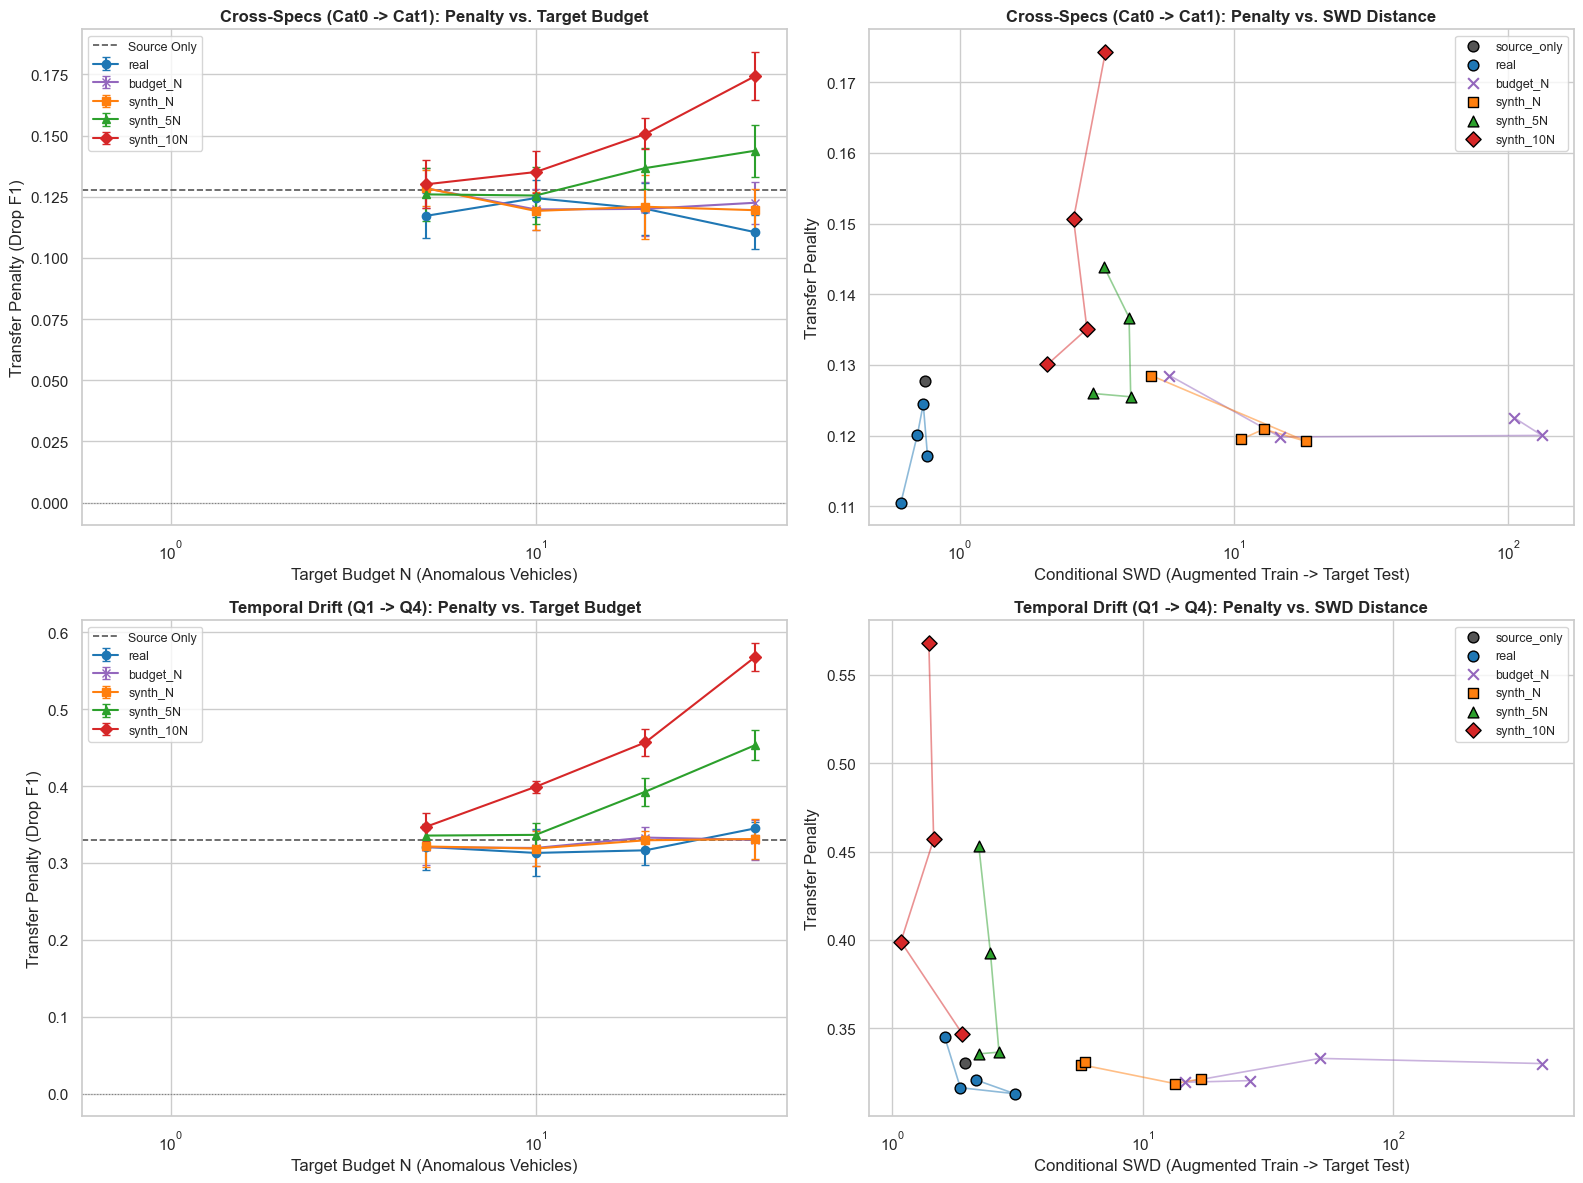

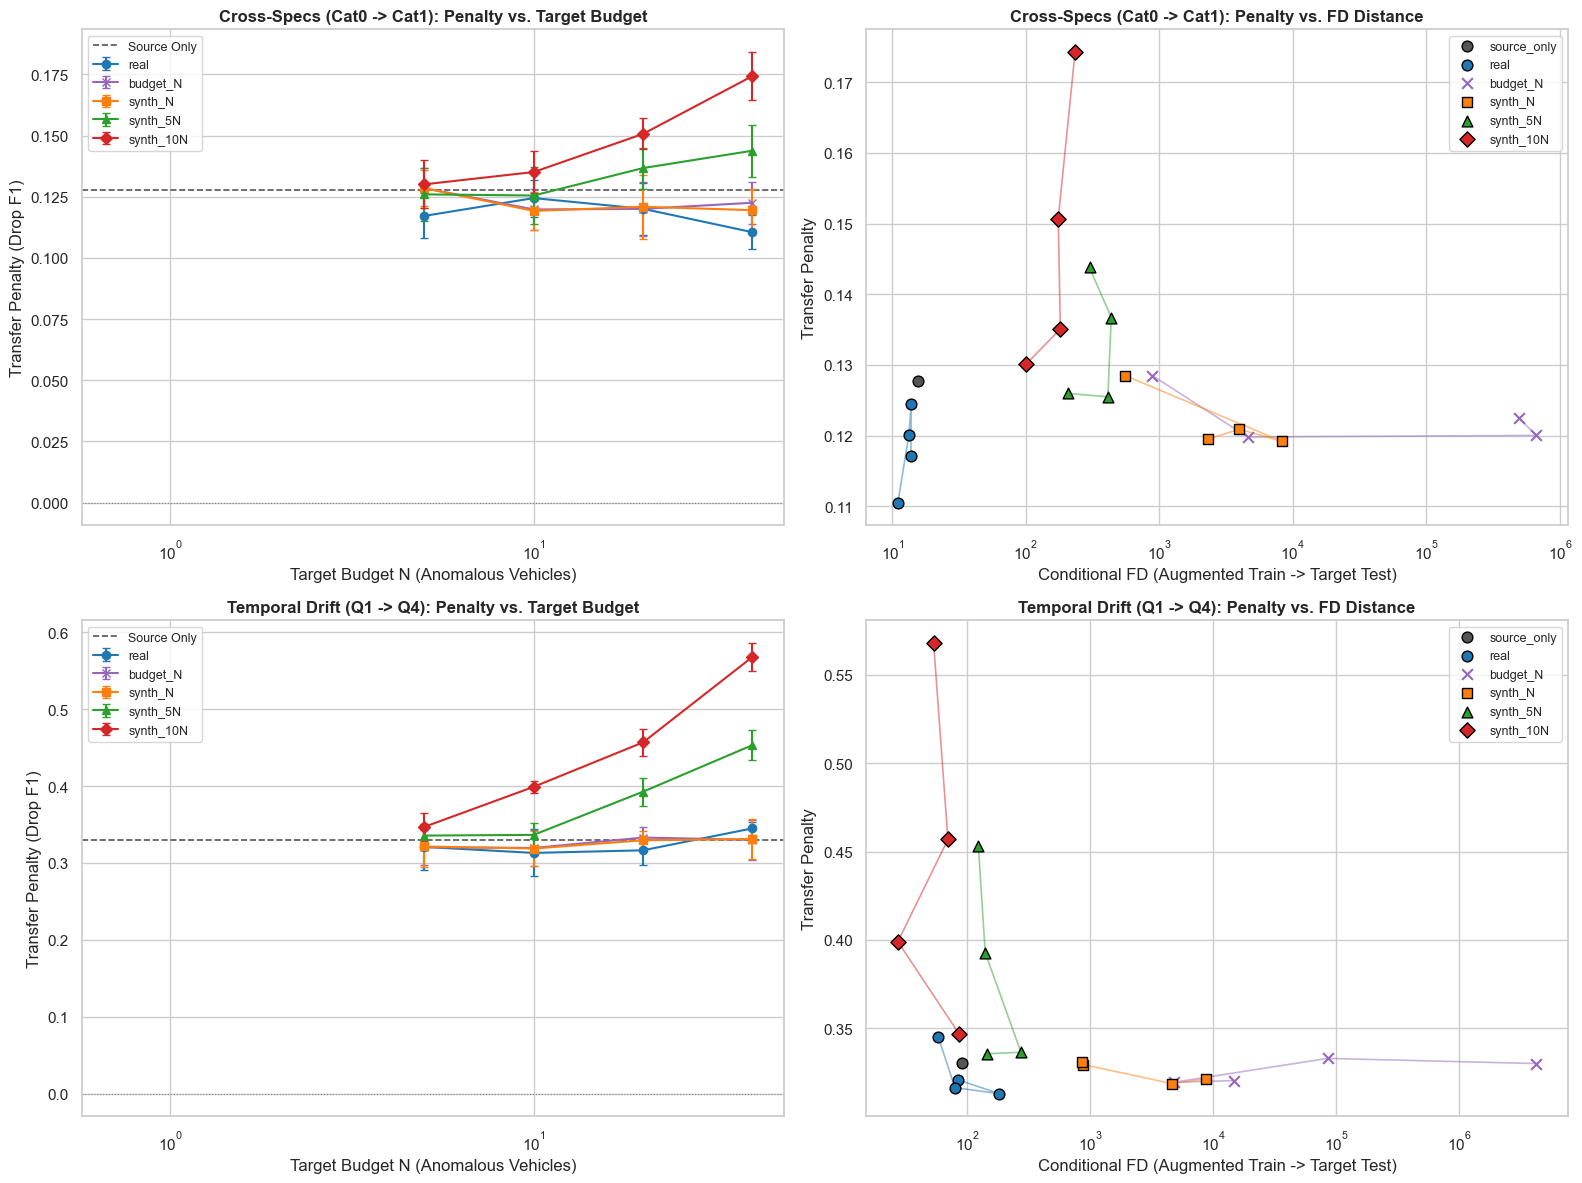

In [10]:
# ==========================================
# 4. AGGREGATION AND VISUALIZATION
# ==========================================
METRICS = ['SWD', 'MMD', 'FD']
SCENARIOS = ['source_only', 'real', 'budget_N', 'synth_N', 'synth_5N', 'synth_10N']

def aggregate_sweep(rows, anchor, n_grid):
    """Aggregates the multi-seed sweep results into a clean statistical summary."""
    anchor_pens, anchor_dist = anchor
    recs = [{'N': 0, 'scenario': 'source_only', 'penalty_mean': np.mean(anchor_pens), 'penalty_std': np.std(anchor_pens),
             **{m: anchor_dist[m] for m in METRICS}}]
    
    for N in n_grid:
        for scen in ['real', 'budget_N', 'synth_N', 'synth_5N', 'synth_10N']:
            sub = [r for r in rows if r['N'] == N and r['scenario'] == scen]
            if not sub: continue
            
            pens = np.concatenate([r['pens'] for r in sub])
            dists = {m: [r['dist'][m] for r in sub if np.isfinite(r['dist'][m])] for m in METRICS}
            
            recs.append({
                'N': N, 'scenario': scen, 'penalty_mean': pens.mean(), 'penalty_std': pens.std(),
                **{m: (np.mean(dists[m]) if dists[m] else np.nan) for m in METRICS}
            })
    return pd.DataFrame(recs)

# Compile Tables
tables = {name: aggregate_sweep(sweep[name], anchors[name], PAIRS[name]['N_GRID']) for name in PAIRS}

SCEN_STYLE = {
    'source_only': dict(color='#555555', ls='--', marker='o'),
    'real': dict(color='#1f77b4', marker='o'),         # Blue
    'budget_N': dict(color='#9467bd', marker='x'),     # Purple
    'synth_N': dict(color='#ff7f0e', marker='s'),      # Orange
    'synth_5N': dict(color='#2ca02c', marker='^'),     # Green
    'synth_10N': dict(color='#d62728', marker='D'),    # Red
}

def plot_pair(name: str, tbl: pd.DataFrame, dist: str, ax_pen: plt.Axes, ax_swd: plt.Axes):
    """Renders the Budget Curve and the Distance-Penalty Trend."""
    src_only = tbl[tbl['N'] == 0].iloc[0]
    sub = tbl[tbl['N'] > 0].copy()
    sub['N'] = sub['N'].astype(int)

    # PANEL 1: Transfer Penalty vs Target Budget N
    ax_pen.set_xscale('log')
    for scen in SCENARIOS:
        if scen == 'source_only':
            ax_pen.axhline(src_only['penalty_mean'], color='#555555', ls='--', lw=1.2, label='Source Only')
            continue
        s = sub[sub['scenario'] == scen]
        if s.empty: continue
        st = SCEN_STYLE[scen]
        ax_pen.errorbar(s['N'], s['penalty_mean'], yerr=s['penalty_std'], 
                        color=st['color'], marker=st['marker'], lw=1.5, capsize=3, label=scen)
        
    ax_pen.axhline(0, color='gray', lw=0.8, ls=':')
    ax_pen.set_xlabel('Target Budget N (Anomalous Vehicles)')
    ax_pen.set_ylabel('Transfer Penalty (Drop F1)')
    ax_pen.set_title(f'{name}: Penalty vs. Target Budget', fontweight='bold', fontsize=12)
    ax_pen.legend(fontsize=9)

    # PANEL 2: Transfer Penalty vs Conditional Distance
    pts = [src_only]
    for scen in SCENARIOS[1:]:
        s = sub[sub['scenario'] == scen]
        if not s.empty: pts.append(s)
        
    for s in pts:
        scen = s['scenario'] if isinstance(s, pd.Series) else s['scenario'].iloc[0]
        st = SCEN_STYLE[scen]
        ax_swd.scatter(s[dist], s['penalty_mean'], color=st['color'], marker=st['marker'], s=60, label=scen, zorder=3, edgecolor='black')
        if scen != 'source_only':
            ax_swd.plot(s[dist], s['penalty_mean'], color=st['color'], lw=1.2, alpha=0.5)
            
    ax_swd.set_xscale('log')
    ax_swd.set_xlabel(f'Conditional {dist} (Augmented Train -> Target Test)')
    ax_swd.set_ylabel('Transfer Penalty')
    ax_swd.set_title(f'{name}: Penalty vs. {dist} Distance', fontweight='bold', fontsize=12)
    ax_swd.legend(fontsize=9)

# Generate final visualizations for SWD and FD
for metric in ['SWD', 'FD']:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    for i, name in enumerate(PAIRS):
        plot_pair(name, tables[name], metric, axes[i, 0], axes[i, 1])
    plt.tight_layout()
    plt.show()